In [1]:
import matplotlib.pyplot as plt
import numpy as np
from FastBEMT import BEMT, Environment, Propeller, Simulation
from FastBEMT.Utils import BladeStressCalculator, Plotter, load_propeller_dict
import scienceplots
plt.style.use(['science', 'no-latex'])

In [2]:
rpm = 7000.0
v_inf = 0.0
material_density = 2700.0  # kg/m^3

propeller_name, geometry = load_propeller_dict('Data/10x7E')[0]
environment = Environment()
simulation = Simulation(
    revolutions=1,
    timesteps_per_revolution=100,
    device='cpu',
)
propeller = Propeller(
    geometry=geometry,
    environment=environment,
    simulation=simulation,
)

In [3]:
bemt = BEMT(
    propeller=propeller,
    environment=environment,
    rpm=rpm,
    v_inf=v_inf,
)
performance = bemt.performance_for()

print(f'Propeller: {propeller_name}')
print(f'Operating point: {rpm:.0f} RPM, hover')
print(f'Thrust: {performance.thrust:.3f} N')
print(f'Torque: {performance.torque:.4f} N m')

Propeller: 10x7E
Operating point: 7000 RPM, hover
Thrust: 8.059 N
Torque: 0.1345 N m


In [4]:
stress_calculator = BladeStressCalculator(propeller)
solution = bemt.solution_for()

# The zero-width tip station may be unsolved. It carries no distributed load,
# so replace any non-finite tip load with zero before cumulative integration.
section_thrust = solution['d_t'].to_numpy()
section_torque = solution['d_q'].to_numpy()
invalid_loads = ~np.isfinite(section_thrust) | ~np.isfinite(section_torque)
if invalid_loads.any():
    print(f'Replacing {invalid_loads.sum()} non-finite section load(s) with zero.')

section_thrust = np.nan_to_num(section_thrust) / geometry['n_blades']
section_torque = np.nan_to_num(section_torque) / geometry['n_blades']
omega = 2.0 * np.pi * rpm / 60.0

sigma_c = stress_calculator.compute_centrifugal_stress(
    material_density,
    omega,
)
sigma_b = stress_calculator.compute_bending_stress(
    section_thrust,
    section_torque,
)
sigma_total = sigma_c[:, None] + sigma_b

peak_index = int(np.argmax(np.max(np.abs(sigma_total), axis=1)))
print(f'Peak centrifugal stress: {np.max(np.abs(sigma_c)) / 1e6:.2f} MPa')
print(f'Peak bending stress: {np.max(np.abs(sigma_b)) / 1e6:.2f} MPa')
print(f'Peak combined stress: {np.max(np.abs(sigma_total)) / 1e6:.2f} MPa')
print(f'Peak combined-stress radius: {geometry["r"][peak_index]:.4f} m')

Replacing 1 non-finite section load(s) with zero.
Peak centrifugal stress: 10.37 MPa
Peak bending stress: 14.02 MPa
Peak combined stress: 17.09 MPa
Peak combined-stress radius: 0.0279 m


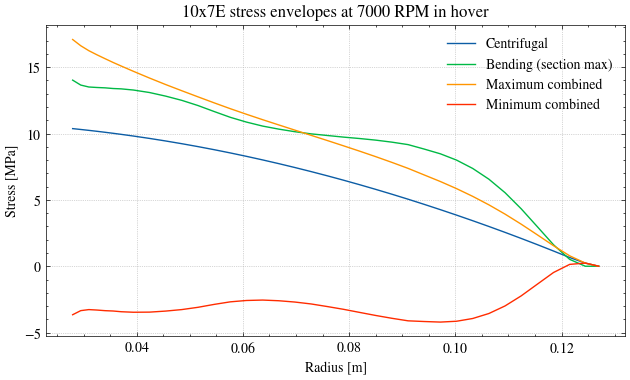

In [5]:
radius = np.asarray(geometry['r'])
max_bending = np.max(np.abs(sigma_b), axis=1) / 1e6
max_tensile = np.max(sigma_total, axis=1) / 1e6
max_compressive = np.min(sigma_total, axis=1) / 1e6

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(radius, sigma_c / 1e6, label='Centrifugal')
ax.plot(radius, max_bending, label='Bending (section max)')
ax.plot(radius, max_tensile, label='Maximum combined')
ax.plot(radius, max_compressive, label='Minimum combined')
ax.set_xlabel('Radius [m]')
ax.set_ylabel('Stress [MPa]')
ax.set_title('10x7E stress envelopes at 7000 RPM in hover')
ax.grid(True, linestyle=':')
ax.legend()
fig.tight_layout()
plt.show()

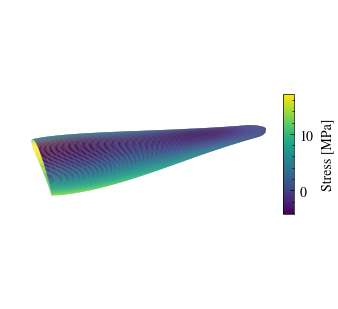

In [6]:
plotter = Plotter(propeller)
plotter.plot_stress_distribution(
    sigma_c=sigma_c,
    sigma_b=sigma_b,
    stress_calculator=stress_calculator,
    figsize=(4.5, 3),
    cmap='viridis',
)